# Baseline CNN â€” Recall

Device: cuda

Train : (7958, 1, 178, 178)  |  1472 seizure / 6486 non-seizure
Val   : (1702, 1, 178, 178)  |  414 seizure / 1288 non-seizure
Test  : (1725, 1, 178, 178)  |  391 seizure / 1334 non-seizure

pos_weight candidates: 3.3047  4.4062  5.5077
Random search: 30 trials x 5-fold CV, max 25 epochs/fold (patience=5)
Trial 01/30 | Recall=0.9817 | lr=5.61e-04  bs=32  dropout=0.3  pw=3.3047
Trial 02/30 | Recall=0.9878 | lr=1.10e-04  bs=32  dropout=0.7  pw=3.3047
Trial 03/30 | Recall=0.9905 | lr=1.67e-03  bs=128  dropout=0.5  pw=4.4062
Trial 04/30 | Recall=0.9871 | lr=1.64e-03  bs=128  dropout=0.3  pw=4.4062
Trial 05/30 | Recall=0.9837 | lr=1.75e-04  bs=128  dropout=0.5  pw=4.4062
Trial 06/30 | Recall=0.9898 | lr=8.69e-03  bs=64  dropout=0.5  pw=5.5077
Trial 07/30 | PRUNED
Trial 08/30 | Recall=0.9878 | lr=3.50e-03  bs=128  dropout=0.7  pw=4.4062
Trial 09/30 | PRUNED
Trial 10/30 | PRUNED
Trial 11/30 | PRUNED
Trial 12/30 | PRUNED
Trial 13/30 | PRUNED
Trial 14/30 | PRUNED
Trial 15/30 | PRU

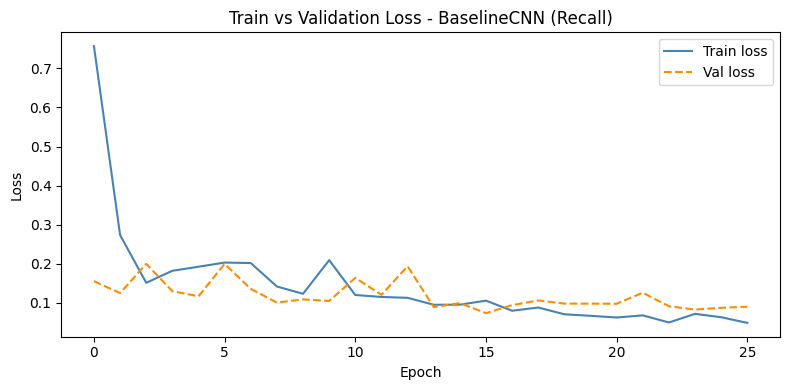

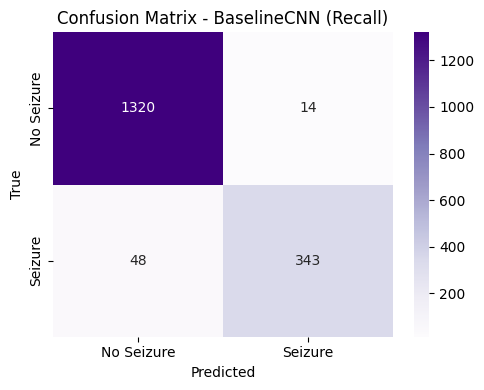

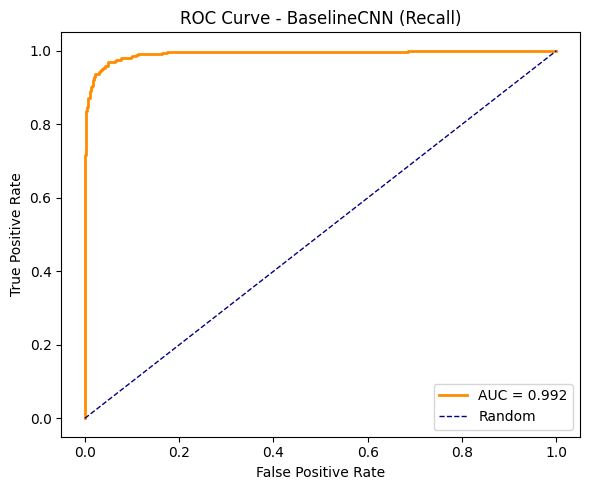

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve)
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import RandomSampler
import os
import random
import time


# STEP 1 - SEED & DEVICE


SEED = 42

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False       # FIX 1a
    torch.backends.cudnn.deterministic = True    # FIX 1b

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


# STEP 2 - LOAD SCALOGRAMS
# Split: X_train used for CV search, X_val for final retraining,
# X_test ONLY for final evaluation.
# pos_weight is computed here because it depends on the loaded labels.


X_train = np.load('scalograms/X_train.npy')
y_train = np.load('scalograms/y_train.npy')
X_val   = np.load('scalograms/X_val.npy')
y_val   = np.load('scalograms/y_val.npy')
X_test  = np.load('scalograms/X_test.npy')
y_test  = np.load('scalograms/y_test.npy')

print(f'\nTrain : {X_train.shape}  |  {int(y_train.sum())} seizure / {int((y_train==0).sum())} non-seizure')
print(f'Val   : {X_val.shape}  |  {int(y_val.sum())} seizure / {int((y_val==0).sum())} non-seizure')
print(f'Test  : {X_test.shape}  |  {int(y_test.sum())} seizure / {int((y_test==0).sum())} non-seizure')

n_neg = int((y_train == 0).sum())
n_pos = int(y_train.sum())
GLOBAL_POS_WEIGHT = round(n_neg / n_pos, 4)
PW_LOW            = round(GLOBAL_POS_WEIGHT * 0.75, 4)
PW_HIGH           = round(GLOBAL_POS_WEIGHT * 1.25, 4)
print(f'\npos_weight candidates: {PW_LOW}  {GLOBAL_POS_WEIGHT}  {PW_HIGH}')


# STEP 3 - DATASET

class ScalogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



# STEP 4 - MODEL  (input: 1Ã—178Ã—178)


class BaselineCNN(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),    # â†’ 32Ã—89Ã—89
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),    # â†’ 64Ã—44Ã—44
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),   # â†’ 128Ã—22Ã—22
        )
        # FIX 2: derive flat_size from actual input dimensions, never hardcode
        with torch.no_grad():
            dummy    = torch.zeros(1, 1, 178, 178)
            flat_size = self.features(dummy).view(1, -1).shape[1]  # 61952

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# STEP 5 - SEARCH CONFIGURATION & HELPERS


N_TRIALS            = 30
N_FOLDS             = 5
MAX_EPOCHS_PER_FOLD = 25
FOLD_PATIENCE       = 5

FINAL_EPOCHS        = 50
WARMUP_EPOCHS       = 5
FINAL_PATIENCE      = 10

CHECKPOINT_PATH     = 'best_baseline_cnn_recall.pt'


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total = 0.0
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx).squeeze(-1), by)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval()
    total = 0.0
    preds, trues = [], []
    with torch.no_grad():
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            logits = model(bx).squeeze(-1)
            total += criterion(logits, by).item()
            prob = torch.sigmoid(logits).cpu().numpy()
            preds.extend((prob > 0.5).astype(int))
            trues.extend(by.cpu().numpy().astype(int))
    return total / len(loader), recall_score(trues, preds, zero_division=0)


# STEP 6 - CV PER TRIAL, MAXIMISING MEAN RECALL

def objective(trial):
    lr         = trial.suggest_float('lr',         1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    dropout    = trial.suggest_categorical('dropout',    [0.3, 0.5, 0.7])
    pos_weight = trial.suggest_categorical('pos_weight', [PW_LOW, GLOBAL_POS_WEIGHT, PW_HIGH])

    skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    full_ds = ScalogramDataset(X_train, y_train)
    fold_recalls = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
        set_seed(SEED + fold)

        tr_loader = DataLoader(Subset(full_ds, tr_idx), batch_size=batch_size, shuffle=True)
        va_loader = DataLoader(Subset(full_ds, va_idx), batch_size=batch_size, shuffle=False)

        model     = BaselineCNN(dropout=dropout).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
        optimizer = optim.Adam(model.parameters(), lr=lr)

        best_val_loss = float('inf')
        best_fold_recall  = 0.0
        no_improve    = 0

        for epoch in range(MAX_EPOCHS_PER_FOLD):
            train_one_epoch(model, tr_loader, criterion, optimizer)
            val_loss, val_recall = eval_epoch(model, va_loader, criterion)

            # Global step across folds so MedianPruner compares trials fairly
            trial.report(val_loss, step=fold * MAX_EPOCHS_PER_FOLD + epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_fold_recall  = val_recall
                no_improve    = 0
            else:
                no_improve += 1
                if no_improve >= FOLD_PATIENCE:
                    break

        fold_recalls.append(best_fold_recall)

    return float(np.mean(fold_recalls))


# STEP 7 - RUN RANDOM SEARCH  (30 trials)
# 

optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = RandomSampler(seed=SEED)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
study   = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)

def trial_callback(study, trial):
    if trial.state == optuna.trial.TrialState.COMPLETE:
        p = trial.params
        print(f'Trial {trial.number+1:02d}/{N_TRIALS} | Recall={trial.value:.4f} | '
              f'lr={p["lr"]:.2e}  bs={p["batch_size"]}  '
              f'dropout={p["dropout"]}  pw={p["pos_weight"]}')
    elif trial.state == optuna.trial.TrialState.PRUNED:
        print(f'Trial {trial.number+1:02d}/{N_TRIALS} | PRUNED')

print(f'Random search: {N_TRIALS} trials x {N_FOLDS}-fold CV, '
      f'max {MAX_EPOCHS_PER_FOLD} epochs/fold (patience={FOLD_PATIENCE})')

t_search_start = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False, callbacks=[trial_callback])
t_search_end = time.time()

n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
n_pruned   = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)

print(f'\nSearch complete.  Completed: {n_complete}  Pruned: {n_pruned}')
print(f'Search time : {(t_search_end - t_search_start)/60:.1f} min')
print(f'Best CV Recall : {study.best_value:.4f}')
print(f'Best params : {study.best_params}')


# 
# STEP 8 - RETRAIN BEST CONFIG ON FULL TRAINING DATA
# Warmup (5 epochs, lr 0.1x â†’ 1x) then cosine annealing to eta_min=1e-6.

set_seed(SEED)
best = study.best_params

train_loader = DataLoader(ScalogramDataset(X_train, y_train), batch_size=best['batch_size'], shuffle=True)
val_loader   = DataLoader(ScalogramDataset(X_val,   y_val),   batch_size=best['batch_size'], shuffle=False)
test_loader  = DataLoader(ScalogramDataset(X_test,  y_test),  batch_size=best['batch_size'], shuffle=False)

model     = BaselineCNN(dropout=best['dropout']).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([best['pos_weight']]).to(device))
optimizer = optim.Adam(model.parameters(), lr=best['lr'])

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS])

best_val_loss = float('inf')
no_improve    = 0
history       = {'train_loss': [], 'val_loss': []}

print(f'Retraining: up to {FINAL_EPOCHS} epochs, warmup={WARMUP_EPOCHS}, patience={FINAL_PATIENCE}\n')

t_retrain_start = time.time()
for epoch in range(FINAL_EPOCHS):
    avg_train      = train_one_epoch(model, train_loader, criterion, optimizer)
    avg_val, _     = eval_epoch(model, val_loader, criterion)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    # FIX 3: checkpoint BEFORE scheduler.step() so saved weights correspond
    # to the LR that was active during the epoch that produced them
    tag = ''
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        no_improve = 0
        tag = '  [saved]'
    else:
        no_improve += 1

    scheduler.step()   # advance LR after checkpointing

    print(f'Epoch {epoch+1:02d}/{FINAL_EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f}{tag}')

    if no_improve >= FINAL_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

# FIX 4: weights_only=True suppresses FutureWarning in recent PyTorch versions
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True))
t_retrain_end = time.time()
print(f'\nLoaded best checkpoint  (val loss: {best_val_loss:.4f})')
print(f'Retraining time : {(t_retrain_end - t_retrain_start)/60:.1f} min')


# STEP 9 - TEST EVALUATION

model.eval()
probs_all, preds_all, true_all = [], [], []
t_eval_start = time.time()
with torch.no_grad():
    for bx, by in test_loader:
        bx   = bx.to(device)
        prob = torch.sigmoid(model(bx).squeeze(-1)).cpu().numpy()
        probs_all.extend(prob.tolist())
        preds_all.extend((prob > 0.5).astype(int).tolist())
        true_all.extend(by.numpy().astype(int).tolist())

f1_test     = f1_score(true_all,     preds_all, zero_division=0)
prec        = precision_score(true_all, preds_all, zero_division=0)
rec         = recall_score(true_all,   preds_all, zero_division=0)
roc_auc     = roc_auc_score(true_all,  probs_all)
cm          = confusion_matrix(true_all, preds_all)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print('\n' + '=' * 55)
print('TEST RESULTS - BaselineCNN (Recall)')
print('=' * 55)
print(f'  F1-score    : {f1_test:.3f}')
print(f'  Precision   : {prec:.3f}')
print(f'  Recall      : {rec:.3f}')
print(f'  Specificity : {specificity:.3f}')
print(f'  ROC-AUC     : {roc_auc:.3f}')
print(f'\n  TP={tp}  FP={fp}  FN={fn}  TN={tn}')

t_eval_end  = time.time()
t_total     = t_search_end - t_search_start + t_retrain_end - t_retrain_start + t_eval_end - t_eval_start
print(f'  Random search   : {(t_search_end  - t_search_start) /60:.1f} min')
print(f'  Retraining      : {(t_retrain_end - t_retrain_start)/60:.1f} min')
print(f'  Test evaluation : {(t_eval_end    - t_eval_start)   :.1f} s')
print(f'  Total           : {t_total/60:.1f} min')




# STEP 10 - PLOTS


os.makedirs('plots', exist_ok=True)

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train loss', color='steelblue')
plt.plot(history['val_loss'],   label='Val loss',   color='darkorange', linestyle='--')
plt.title('Train vs Validation Loss - BaselineCNN (Recall)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.savefig('plots/cnn_recall_loss.png', dpi=100)
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Seizure', 'Seizure'],
            yticklabels=['No Seizure', 'Seizure'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - BaselineCNN (Recall)')
plt.tight_layout()
plt.savefig('plots/cnn_recall_confusion.png', dpi=100)
plt.show()

fpr, tpr, _ = roc_curve(true_all, probs_all)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BaselineCNN (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/cnn_recall_roc.png', dpi=100)
plt.show()